In [1]:
prefix = '/home/ines/repositories/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [2]:
""" 
IMPORTS
"""
import os
import numpy as np
import pickle
import pandas as pd
from one.api import ONE
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from matplotlib.colors import ListedColormap
import seaborn as sns

# Get my functions
from functions import idxs_from_files
from functions_states import align_bin_design_matrix, states_per_trial_phase, broader_label
from functions_states import define_trial_types, rescale_sequence, plot_binned_sequence

one = ONE(mode='remote')

## Analyses

In [3]:
all_training_states = pd.read_parquet('training_states_wheel_10_05_2026')

In [4]:
all_training_states['abs_wheel_vel'] = np.abs(all_training_states['avg_wheel_vel'])
all_training_states_truncated = all_training_states.loc[all_training_states['trial_id']<=55]


In [5]:
save_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/training_data/'
training_times = pd.read_parquet(save_path + 'training_time_05-05-2026')
training_times['log_training'] = np.log(training_times['training_days'])

In [6]:
training_times = training_times.loc[training_times.training_days>3] # Remove PL034

In [67]:
import seaborn as sns
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# lda_df = pd.read_pickle(data_path+'extended_mouse_LDA_5_bins_cut')
lda_df = pd.read_pickle(data_path+'mouse_LDA_5_bins_cut')
lda_mouse = lda_df.groupby(['mouse_name'])[0].mean().reset_index()

## Test various things

In [57]:
grouped_df = all_training_states_truncated.groupby(['session', 'mouse_name', 'broader_label'])['abs_wheel_vel'].mean().reset_index()
# grouped_df = all_training_states_truncated.groupby(['session', 'mouse_name'])['abs_wheel_vel'].mean().reset_index()

In [ ]:
merged = grouped_df.merge(training_times, on=['mouse_name'])

In [24]:
grouped_df = all_training_states_truncated.groupby(['session', 'mouse_name', 'broader_label'])['reaction'].mean().reset_index()
grouped_df = all_training_states_truncated.groupby(['session', 'mouse_name', 'broader_label'])['abs_wheel_vel'].mean().reset_index()
merged = grouped_df.merge(lda_mouse, on=['mouse_name'])
merged = merged.rename(columns={0:'lda_1'})

In [67]:
all_training_states['abs_wheel_disp'] = np.abs(all_training_states['avg_wheel_vel'])
import pandas as pd

# 1. Define your time bin width (dt)
# If bins are 20ms, dt = 0.02. 
# If not constant, you can calculate it:
# df['dt'] = df['time_bins'].diff().fillna(0)
dt = 0.02 

# 3. If you just want the TOTAL displacement per group (not the time-course):
total_displacement = (all_training_states.groupby(['mouse_name', 'session', 'trial_id', 'broader_label'])['abs_wheel_disp'].sum() * dt).reset_index()

In [ ]:
epoch_length = (all_training_states.groupby(['mouse_name', 'session', 'trial_id', 'broader_label'])['Bin'].count()).reset_index()
epoch_length = (epoch_length.groupby(['mouse_name', 'session', 'broader_label'])['Bin'].median()).reset_index()
merged = epoch_length.merge(lda_mouse, on=['mouse_name'])
merged = merged.rename(columns={0:'lda_1'})

Group: Choice
  Pearson r: 0.136
  p-value:   3.232e-01
--------------------
Group: ITI
  Pearson r: -0.263
  p-value:   5.202e-02
--------------------
Group: Pre-quiescence
  Pearson r: -0.341
  p-value:   1.092e-02
--------------------
Group: Quiescence
  Pearson r: -0.099
  p-value:   4.699e-01
--------------------


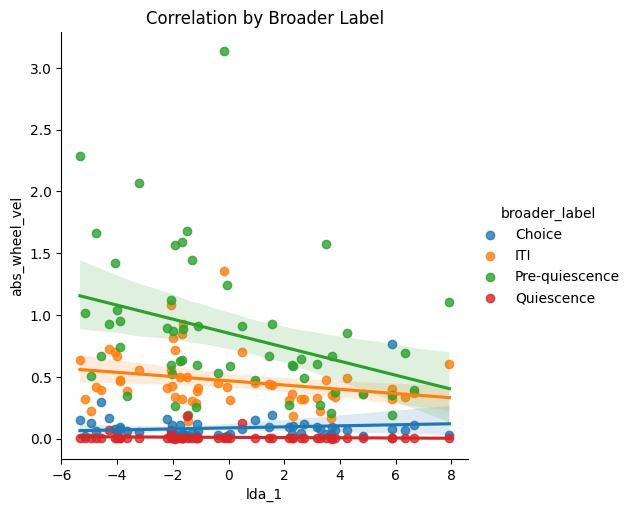

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

test_var = 'Bin'
# test_var = 'abs_wheel_var'
test_var = 'abs_wheel_vel'

correlate = 'log_training'
correlate = 'lda_1'
grouped_df = all_training_states_truncated.groupby(['session', 'mouse_name', 'broader_label'])['abs_wheel_vel'].mean().reset_index()
# grouped_df = all_training_states_truncated.groupby(['session', 'mouse_name'])['abs_wheel_vel'].mean().reset_index()
merged = grouped_df.merge(training_times, on=['mouse_name'])
merged = grouped_df.merge(lda_mouse, on=['mouse_name'])
merged = merged.rename(columns={0:'lda_1'})

# 1. Use lmplot to handle multiple regression lines by hue
g = sns.lmplot(x=correlate, y=test_var, data=merged, hue='broader_label', ci=95)

# 2. Statistical Testing: Calculate correlation for each hue group
labels = merged['broader_label'].unique()

for label in labels:
    # Filter data for the specific group
    subset = merged[merged['broader_label'] == label]
    
    # Calculate Pearson correlation
    # We use .values to ensure we are passing arrays to scipy
    r, p = stats.pearsonr(subset[correlate], subset[test_var])
    
    print(f"Group: {label}")
    print(f"  Pearson r: {r:.3f}")
    print(f"  p-value:   {p:.3e}")
    print("-" * 20)

plt.title('Correlation by Broader Label')
plt.show()

  Pearson r: -0.336
  p-value:   1.221e-02
--------------------


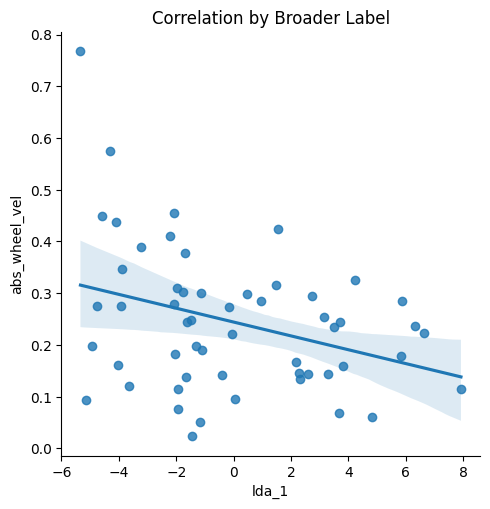

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

test_var = 'Bin'
# test_var = 'abs_wheel_var'
test_var = 'abs_wheel_vel'
correlate = 'log_training'
correlate='lda_1'

grouped_df = all_training_states_truncated.groupby(['session', 'mouse_name', 'broader_label'])['abs_wheel_vel'].mean().reset_index()
grouped_df = all_training_states_truncated.groupby(['session', 'mouse_name'])['abs_wheel_vel'].mean().reset_index()
merged = grouped_df.merge(training_times, on=['mouse_name'])
merged = grouped_df.merge(lda_mouse, on=['mouse_name'])
merged = merged.rename(columns={0:'lda_1'})

# 1. Use lmplot to handle multiple regression lines by hue
g = sns.lmplot(x=correlate, y=test_var, data=merged,ci=95)

# Calculate Pearson correlation
# We use .values to ensure we are passing arrays to scipy
r, p = stats.pearsonr(merged[correlate], merged[test_var])

print(f"  Pearson r: {r:.3f}")
print(f"  p-value:   {p:.3e}")
print("-" * 20)

plt.title('Correlation by Broader Label')
plt.show()

## Wheel states

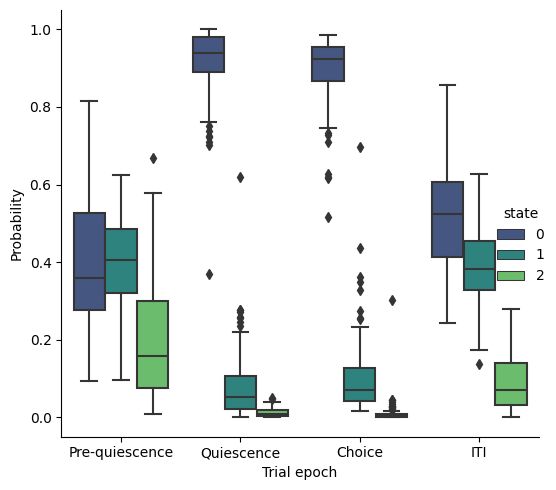

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the ratios (normalize=True gives probabilities instead of counts)
state_ratios = (all_training_states_truncated
                .groupby(['mouse_name', 'session', 'broader_label'])['most_likely_states']
                .value_counts(normalize=True)
                .reset_index(name='probability'))
state_ratios = state_ratios.rename(columns={'most_likely_states': 'state'})

# 3. Plotting the probabilities for each state
# We use a facet grid or 'col' to see the 3 states separately
g = sns.catplot(
    data=state_ratios, 
    x='broader_label', 
    y='probability', 
    hue='state',
    order = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI'],
    # col='state',        # Separate plot for each state
    kind='box',         # Boxplot shows the distribution across sessions/mice
    palette='viridis'
)

g.set_axis_labels("Trial epoch", "Probability")
g.set_titles("State {col_name}")
plt.tight_layout()
plt.show()

--- Statistical Results: Correlation between LDA_1 and State Probability ---
State 0 | Label Choice:
  Pearson r: 0.178, p-val: 1.985e-01
State 0 | Label ITI:
  Pearson r: 0.241, p-val: 7.581e-02
State 0 | Label Pre-quiescence:
  Pearson r: 0.414, p-val: 1.664e-03
State 1 | Label Choice:
  Pearson r: 0.054, p-val: 6.956e-01
State 1 | Label ITI:
  Pearson r: -0.031, p-val: 8.233e-01
State 1 | Label Pre-quiescence:
  Pearson r: -0.172, p-val: 2.080e-01
State 2 | Label Choice:
  Pearson r: 0.177, p-val: 2.142e-01
State 2 | Label ITI:
  Pearson r: -0.344, p-val: 1.013e-02
State 2 | Label Pre-quiescence:
  Pearson r: -0.329, p-val: 1.526e-02


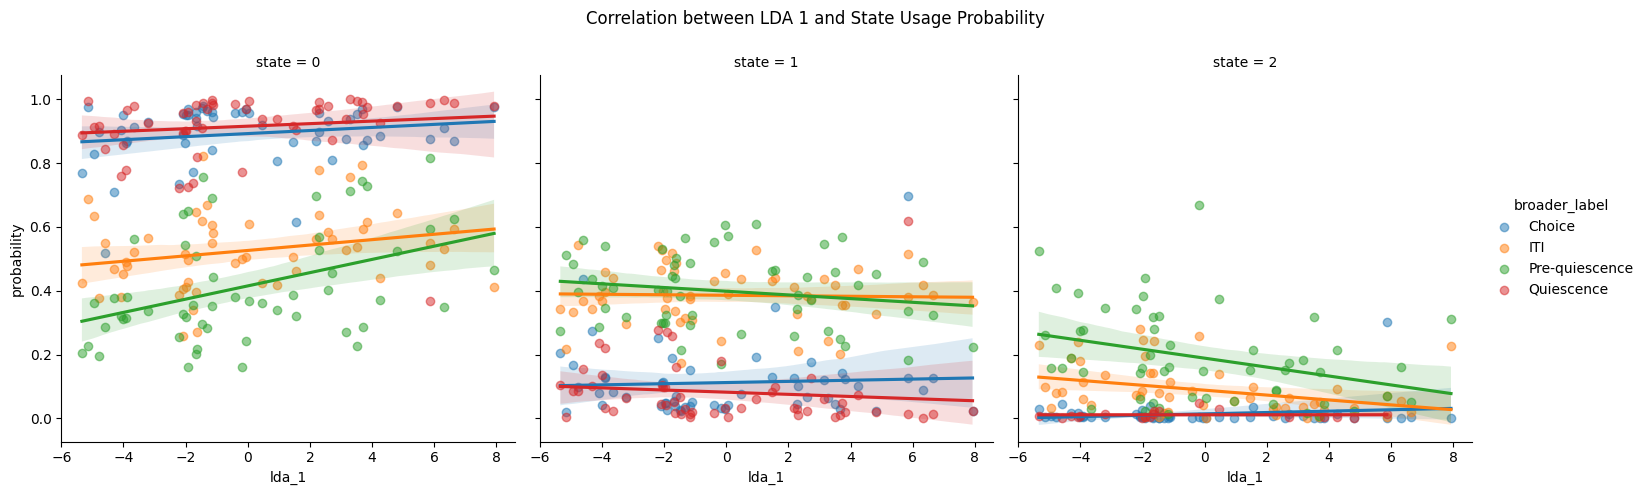

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

state_ratios = (all_training_states_truncated
                .groupby(['mouse_name', 'session', 'broader_label'])['most_likely_states']
                .value_counts(normalize=True)
                .reset_index(name='probability'))
state_ratios = state_ratios.rename(columns={'most_likely_states': 'state'})

merged = state_ratios.merge(training_times, on=['mouse_name'])
merged = state_ratios.merge(lda_mouse, on=['mouse_name'])
merged = merged.rename(columns={0: 'lda_1'})
var = 'log_training'
var = 'lda_1'

# 2. Plot correlation of state probability vs LDA 1
# We facet by 'state' (columns) and color-code by 'broader_label' (hue)
g = sns.lmplot(
    data=merged, 
    x=var, 
    y='probability', 
    hue='broader_label', 
    col='state', 
    ci=95, 
    scatter_kws={'alpha':0.5}
)

# 3. Statistical Testing: Calculate correlation for every combination of State and Label
print("--- Statistical Results: Correlation between LDA_1 and State Probability ---")
states = merged['state'].unique()
labels = merged['broader_label'].unique()
labels = ['Choice', 'ITI', 'Pre-quiescence']
for s in states:
    for l in labels:
        subset = merged[(merged['state'] == s) & (merged['broader_label'] == l)]
        
        # Ensure we have enough data points to correlate
        if len(subset) > 2:
            r, p = stats.pearsonr(subset[var], subset['probability'])
            print(f"State {s} | Label {l}:")
            print(f"  Pearson r: {r:.3f}, p-val: {p:.3e}")
        else:
            print(f"State {s} | Label {l}: Not enough data points.")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Correlation between LDA 1 and State Usage Probability')
plt.show()

--- Statistical Results: Correlation per State ---
State 0:
  Pearson r: 0.151
  p-value:   2.709e-01
  n = 55 sessions
--------------------
State 1:
  Pearson r: -0.034
  p-value:   8.053e-01
  n = 55 sessions
--------------------
State 2:
  Pearson r: -0.394
  p-value:   2.937e-03
  n = 55 sessions
--------------------


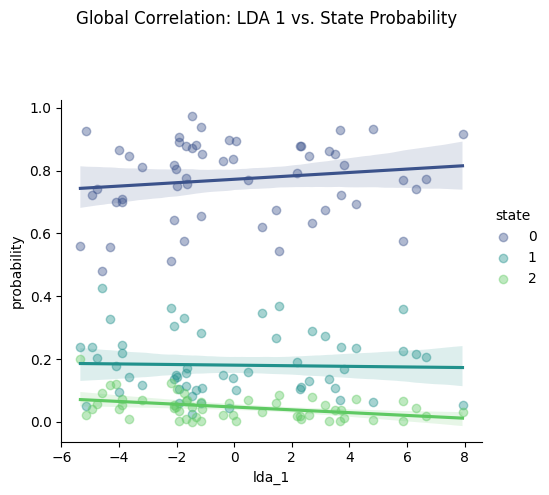

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Calculate the ratios (normalize=True gives probabilities instead of counts)
state_ratios = (all_training_states_truncated
                .groupby(['mouse_name', 'session'])['most_likely_states']
                .value_counts(normalize=True)
                .reset_index(name='probability'))
state_ratios = state_ratios.rename(columns={'most_likely_states': 'state'})

merged = state_ratios.merge(training_times, on=['mouse_name'])
merged = state_ratios.merge(lda_mouse, on=['mouse_name'])
merged = merged.rename(columns={0: 'lda_1'})
var = 'log_training'
var = 'lda_1'

# 1. Plot correlation of state probability vs LDA 1
# We facet by 'state' so we get one plot per state, but no split by label
g = sns.lmplot(
    data=merged, 
    x=var, 
    y='probability', 
    hue='state', 
    ci=95, 
    # line_kws={'color': 'red'},  # Make the regression line stand out
    scatter_kws={'alpha':0.4},
    palette='viridis'
)

# 2. Statistical Testing: Calculate correlation for each State (all labels combined)
print("--- Statistical Results: Correlation per State ---")
states = sorted(merged['state'].unique())

for s in states:
    subset = merged[merged['state'] == s]
    
    if len(subset) > 2:
        r, p = stats.pearsonr(subset[var], subset['probability'])
        print(f"State {s}:")
        print(f"  Pearson r: {r:.3f}")
        print(f"  p-value:   {p:.3e}")
        print(f"  n = {len(subset)} sessions")
        print("-" * 20)

plt.subplots_adjust(top=0.8)
g.fig.suptitle('Global Correlation: LDA 1 vs. State Probability')
plt.show()

# Wheel sequence analyses

In [12]:
all_sequences = pd.read_parquet('wheel_sequences_sess_1_11_05_2026')
all_sequences = pd.read_parquet('wheel_cont_sequences_sess_1_11_05_2026')

In [13]:
all_sequences['session'] = all_sequences['sample'].str[:36]
var_name = 'most_likely_states_binned_sequence'
var_name = 'avg_wheel_vel_binned_sequence'
design_df = all_sequences.pivot(index=['sample', 'trial_type', 'mouse_name', 'session'], columns=['broader_label'], values=var_name).reset_index().dropna()
var_names = design_df.keys()[-4:]

epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
sequences_choice = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape
# use_sequences = sequences_choice[~np.isnan(sequences_choice).any(axis=1)]
use_sequences = sequences_choice

In [148]:
from sklearn.preprocessing import StandardScaler,  LabelBinarizer

epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
sequences_choice = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape
use_sequences = sequences_choice[~np.isnan(sequences_choice).any(axis=1)]

# Transform in paw states
use_states = int(max(np.unique(use_sequences)))+1
timesteps = np.shape(use_sequences)[1]
binarized = np.zeros((np.shape(use_sequences)[0], timesteps*use_states))

for t in range(timesteps):
    label_binarizer = LabelBinarizer()
    label_binarizer.fit(range(use_states))
    encoded_arr = label_binarizer.transform(use_sequences[:, t])
    binarized[:, t*use_states:(t+1)*use_states] = encoded_arr

In [149]:
np.shape(use_sequences)

(26734, 40)

In [15]:
# sequences_df = pd.DataFrame(binarized)
sequences_df = pd.DataFrame(use_sequences)

sequences_df['sample'] = design_df.reset_index()['sample']
sequences_df['mouse_name'] = design_df.reset_index()['mouse_name']
sequences_df['session'] = design_df.reset_index()['session']
sequences_df['trial_type'] = design_df.reset_index()['trial_type']
sequences_df['trial_id'] = sequences_df['sample'].str.split().str[1:2].str.join('').astype(float)
sequences_df = sequences_df.loc[sequences_df['trial_id']<=55]

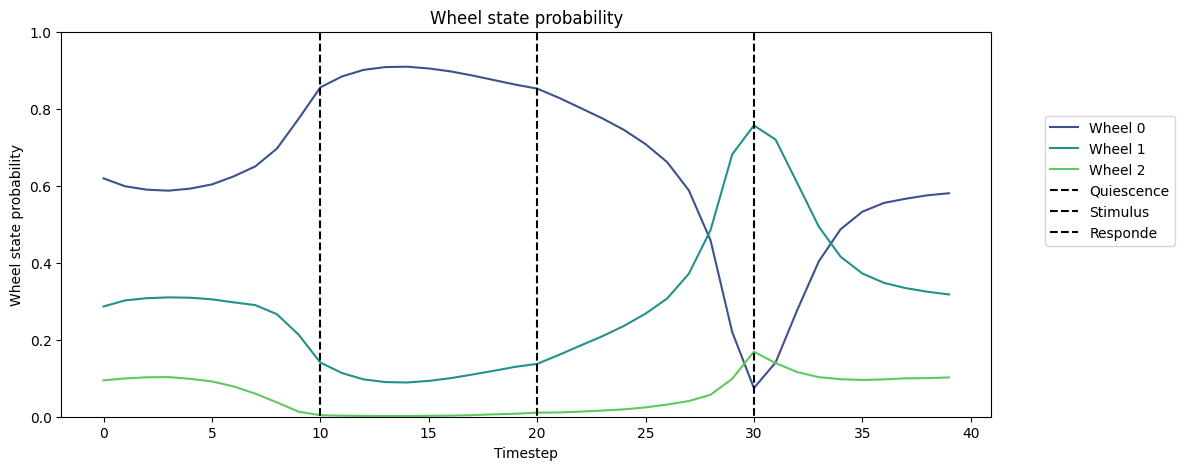

In [164]:
timesteps = 40
reshaped_states = binarized.reshape(np.shape(binarized)[0], timesteps, 3)

plt.figure(figsize=(12, 5))
time_axis = np.arange(timesteps)

# Plot average importance of Paw states vs Whisk vs Lick
palette = sns.color_palette('viridis', 3)
for i, state in enumerate([0, 1, 2]):
    plt.plot(time_axis, reshaped_states[:, :, i].mean(axis=0), label=f'Wheel {state}', color=palette[state], alpha=1, lw=1.5)
    
plt.vlines(10, -10, 30, color='k', linestyle='--', label='Quiescence')
plt.vlines(20, -10, 30, color='k', linestyle='--', label='Stimulus')
plt.vlines(30, -10, 30, color='k', linestyle='--', label='Responde')

plt.ylim([0, 1])
plt.title('Wheel state probability')
plt.xlabel('Timestep')
plt.ylabel('Wheel state probability')
plt.legend(
    title='',
    bbox_to_anchor=(1.05, .8),
    loc='upper left')
plt.show()

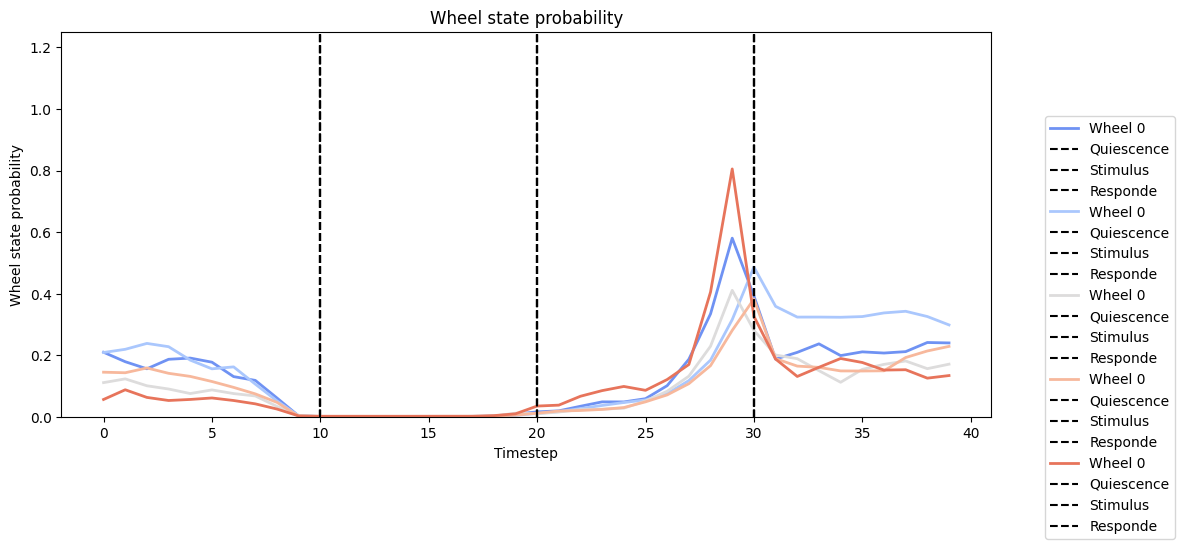

In [22]:
lda_mouse['lda_1_bin'] = pd.cut(lda_mouse[0], 5)
# lda_mouse['lda_1_bin'] = pd.cut(lda_mouse[0], bins=6)
# training_times['training_time_bin'] = pd.qcut(training_times['log_training'], 3)

use_df = sequences_df.merge(lda_mouse[['mouse_name', 'lda_1_bin']], on='mouse_name')
# use_df = sequences_df.merge(training_times[['mouse_name', 'training_time_bin']], on='mouse_name')
bins = lda_mouse['lda_1_bin'].unique().sort_values()
# bins = training_times['training_time_bin'].unique().sort_values()
plt.figure(figsize=(12, 5))
palette=sns.color_palette('coolwarm', 5)
for b, bin in enumerate(bins):
    bin_data = use_df.loc[use_df['lda_1_bin']==bin]
    # bin_data = np.array(bin_data[np.arange(0, 120, 1)])
    bin_data = np.array(bin_data[np.arange(0, 40, 1)])
    timesteps = 40
    # reshaped_states = bin_data.reshape(np.shape(bin_data)[0], timesteps, 3)
    reshaped_states = bin_data
    time_axis = np.arange(timesteps)

    # for i, state in enumerate([0, 1, 2]):
    #     plt.plot(time_axis, reshaped_states[:, :, i].mean(axis=0), label=f'Wheel {state}', color=palette[state], alpha=.15*(b+1), lw=1)
    plt.plot(time_axis, reshaped_states.mean(axis=0), label=f'Wheel {state}', color=palette[b], alpha=1, lw=2)
    plt.vlines(10, -10, 30, color='k', linestyle='--', label='Quiescence')
    plt.vlines(20, -10, 30, color='k', linestyle='--', label='Stimulus')
    plt.vlines(30, -10, 30, color='k', linestyle='--', label='Responde')

    plt.ylim([0, 1.25])
    plt.title('Wheel state probability')
    plt.xlabel('Timestep')
    plt.ylabel('Wheel state probability')
    plt.legend(
        title='',
        bbox_to_anchor=(1.05, .8),
        loc='upper left')
plt.show()

In [82]:
import seaborn as sns
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# lda_df = pd.read_pickle(data_path+'extended_mouse_LDA_5_bins_cut')
lda_df = pd.read_pickle(data_path+'mouse_LDA_5_bins_cut')
lda_mouse = lda_df.groupby(['mouse_name'])[0].mean().reset_index()

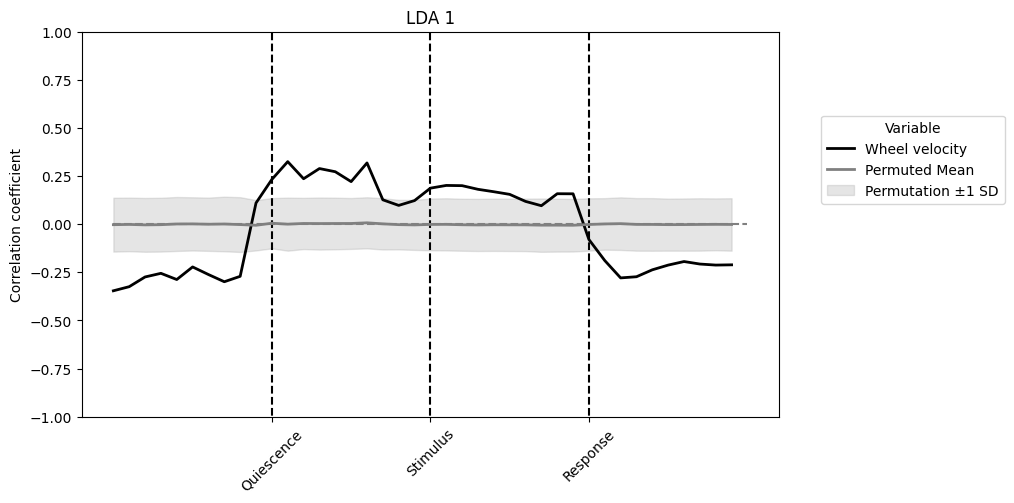

In [83]:
from scipy.stats import pearsonr
iter = 500
plt.figure(figsize=(9, 5))

all_sequences['session'] = all_sequences['sample'].str[:36]

design_df = all_sequences.pivot(index=['sample', 'trial_type', 'mouse_name', 'session'], columns=['broader_label'], values=var_name).reset_index().dropna()
var_names = design_df.keys()[-4:]
epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
sequences_choice = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape
use_sequences = np.abs(sequences_choice)

sequences_df = pd.DataFrame(use_sequences)
sequences_df['sample'] = design_df.reset_index()['sample']
sequences_df['mouse_name'] = design_df.reset_index()['mouse_name']
sequences_df['session'] = design_df.reset_index()['session']
sequences_df['trial_type'] = design_df.reset_index()['trial_type']
sequences_df['trial_id'] = sequences_df['sample'].str.split().str[1:2].str.join('').astype(float)

lda_mouse = lda_mouse.rename(columns={0:'lda_1'})
use_df = sequences_df.merge(lda_mouse[['mouse_name', 'lda_1']], on=['mouse_name'])
use_df = use_df.groupby(['mouse_name', 'lda_1'])[np.arange(0, 40, 1)].mean().reset_index()
struct_coeffs = np.array([
    pearsonr(use_df['lda_1'], np.array(use_df[i]))[0] 
    for i in range(40)])

time_axis = np.arange(timesteps)
plt.vlines(10, -10, 30, color='k', linestyle='--')
plt.vlines(20, -10, 30, color='k', linestyle='--')
plt.vlines(30, -10, 30, color='k', linestyle='--')
plt.hlines(0, -0, 40, color='grey', linestyle='--')

plt.plot(time_axis, struct_coeffs, color='black', label='Wheel velocity', linewidth=2)
permuted_df = np.ones((iter, 40)) * np.nan
for i in range(iter):
    shuffle_df = use_df.copy()
    np.random.shuffle(shuffle_df['lda_1'].values)
    permuted_df[i, :] = np.array([
        pearsonr(shuffle_df['lda_1'], np.array(shuffle_df[i]))[0] 
        for i in range(40)])

perm_mean = permuted_df.mean(axis=0)
perm_std = permuted_df.std(axis=0) # / np.sqrt(iter)
lower_bound = perm_mean - perm_std
upper_bound = perm_mean + perm_std

plt.plot(time_axis, perm_mean, color='grey', linewidth=2, label='Permuted Mean')
plt.fill_between(time_axis, lower_bound, upper_bound, color='grey', alpha=0.2, label='Permutation ±1 SD')

plt.ylim([-1, 1])
plt.title('LDA 1')
plt.ylabel('Correlation coefficient')
plt.legend(
    title='Variable',
    bbox_to_anchor=(1.05, .8),
    loc='upper left')
plt.xticks([10, 20, 30], ['Quiescence', 'Stimulus', 'Response'], rotation=45)
plt.show()

In [91]:

lda_mouse = lda_mouse.rename(columns={0:'lda_1'})
use_df = sequences_df.merge(lda_mouse[['mouse_name', 'lda_1']], on=['mouse_name'])

In [98]:
use_df[['session', 'mouse_name']].drop_duplicates().to_csv('session_1.csv', index=False)